<a href="https://colab.research.google.com/github/MDAYAN0511/-internSpark-Intership-project-2-/blob/main/loan_approval_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df = pd.read_csv("/content/loan_approval_dataset.csv.zip", compression='zip')

In [6]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


(614, 13)

In [7]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [8]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


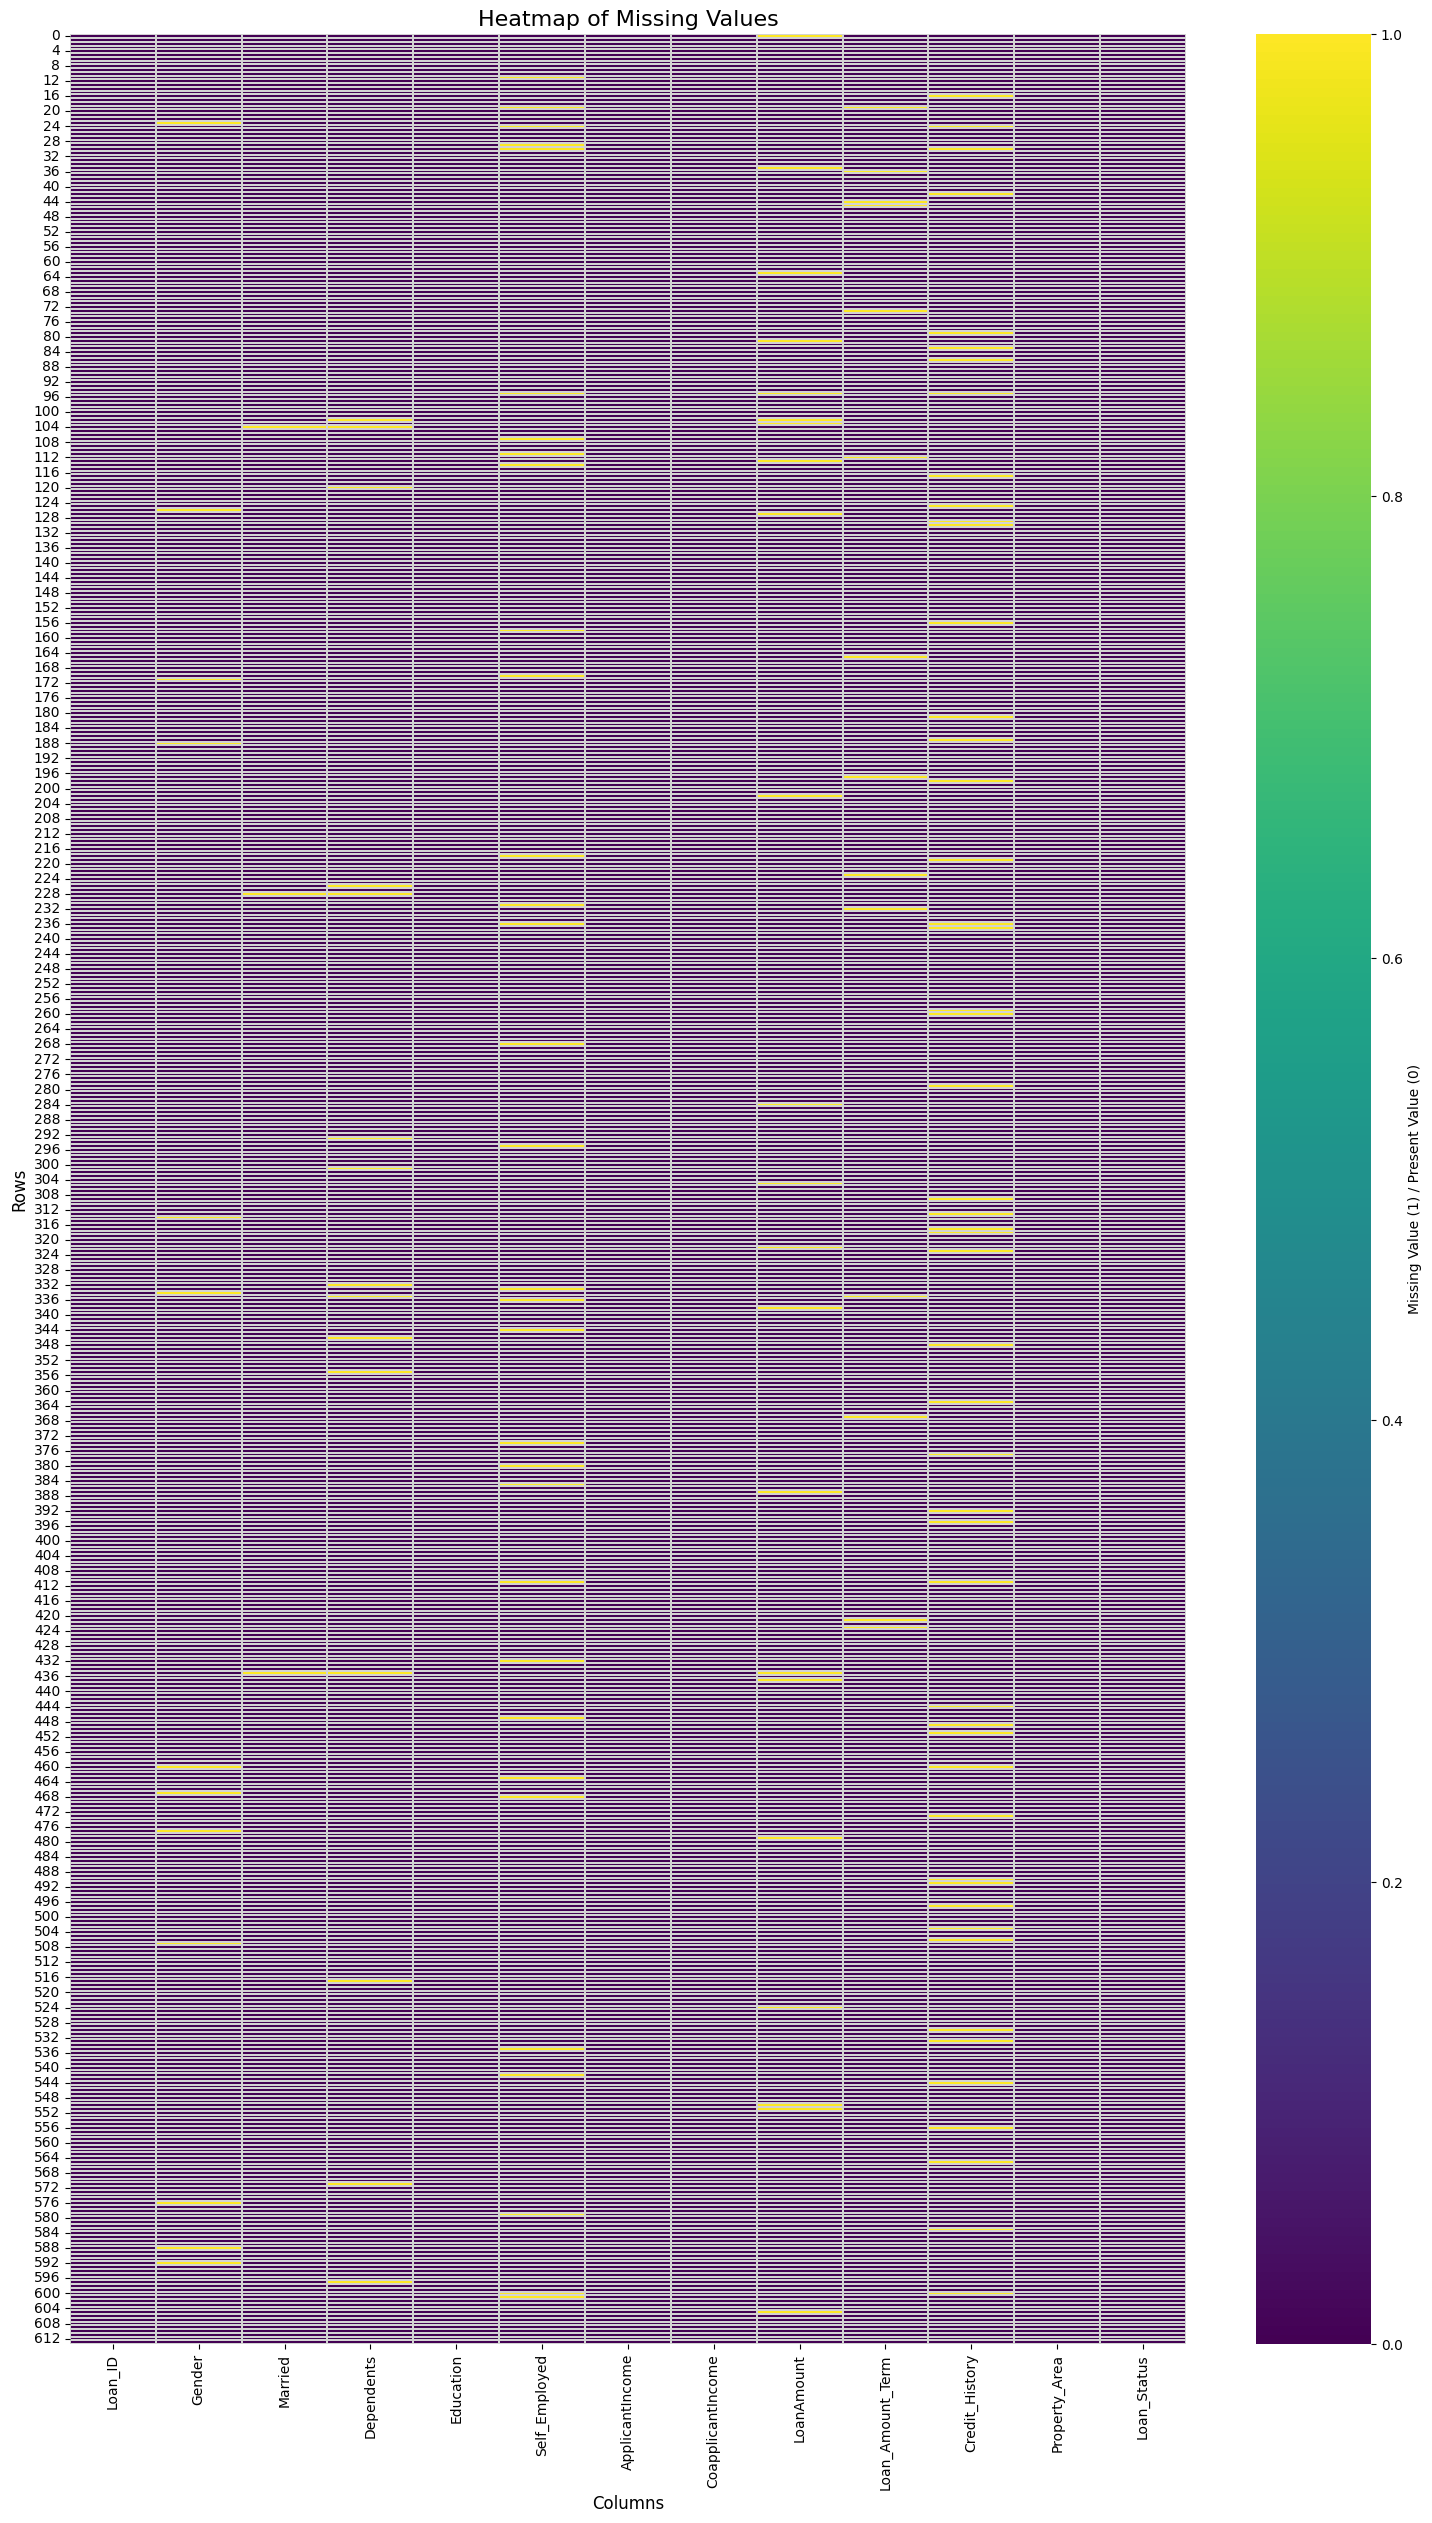

In [12]:
plt.figure(figsize=(18, 30)) # Significantly increase figure height to make each row appear as a distinct box
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', linecolor='lightgray', linewidths=0.1, cbar_kws={'label': 'Missing Value (1) / Present Value (0)'})
plt.title('Heatmap of Missing Values', fontsize=16)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows', fontsize=12)
plt.show()

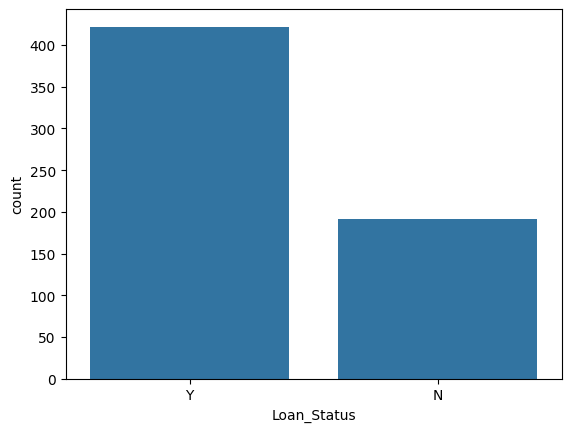

In [14]:
sns.countplot(x='Loan_Status', data=df)
plt.show()

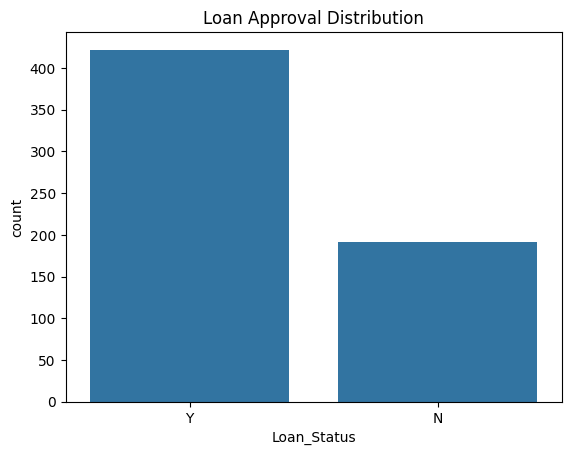

In [16]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

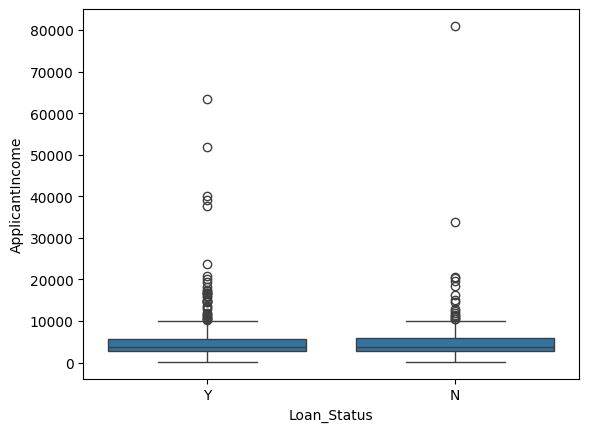

In [18]:
sns.boxplot(x='Loan_Status',
            y='ApplicantIncome',
            data=df)
plt.show()

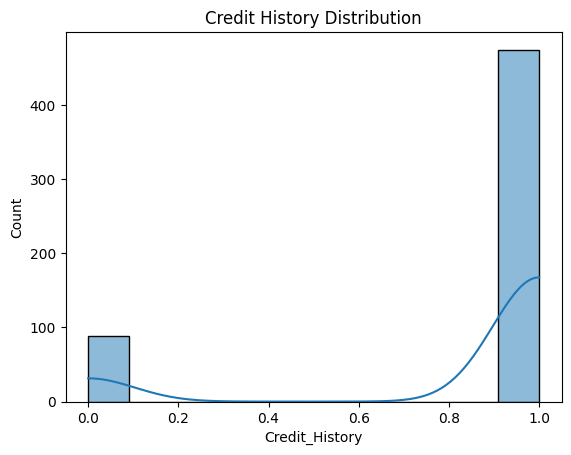

In [20]:
sns.histplot(df['Credit_History'], kde=True)
plt.title("Credit History Distribution")
plt.show()

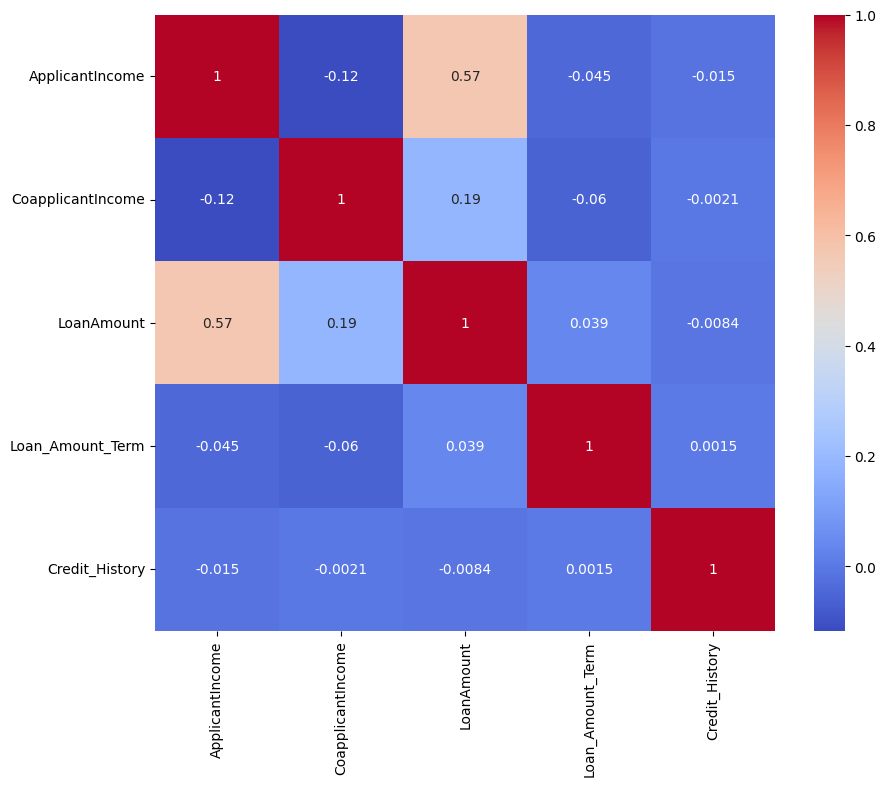

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

In [22]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

In [23]:
cat_imputer = SimpleImputer(strategy='most_frequent')

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns.tolist()
if 'Loan_ID' in categorical_columns:
    categorical_columns.remove('Loan_ID')

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [26]:
pd.get_dummies(df, drop_first=True)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,...,Loan_ID_LP002959,Loan_ID_LP002960,Loan_ID_LP002961,Loan_ID_LP002964,Loan_ID_LP002974,Loan_ID_LP002978,Loan_ID_LP002979,Loan_ID_LP002983,Loan_ID_LP002984,Loan_ID_LP002990
0,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,...,False,False,False,False,False,False,False,False,False,False
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,...,False,False,False,False,False,False,False,False,False,False
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,...,False,False,False,False,False,False,False,False,False,False
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,...,False,False,False,False,False,True,False,False,False,False
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,...,False,False,False,False,False,False,True,False,False,False
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,...,False,False,False,False,False,False,False,True,False,False
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,...,False,False,False,False,False,False,False,False,True,False


In [28]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
y = df['Loan_Status']
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)

# Identify numerical columns with missing values in X
num_cols_with_missing = X[['LoanAmount', 'Loan_Amount_Term', 'Credit_History']].columns

# Impute missing numerical values in X
X[num_cols_with_missing] = num_imputer.fit_transform(X[num_cols_with_missing])

# Initialize and apply the StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
y.value_counts()

,count
Loan_Status,
1,422
0,192


In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

In [45]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# --- Logistic Regression Metrics ---
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)

precision_lr = report_lr['1']['precision']
recall_lr = report_lr['1']['recall']
f1_lr = report_lr['1']['f1-score']
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

# --- Decision Tree Metrics ---
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)

precision_dt = report_dt['1']['precision']
recall_dt = report_dt['1']['recall']
f1_dt = report_dt['1']['f1-score']
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

# --- Random Forest Metrics ---
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

precision_rf = report_rf['1']['precision']
recall_rf = report_rf['1']['recall']
f1_rf = report_rf['1']['f1-score']
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Create a DataFrame to display the results
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Precision': [precision_lr, precision_dt, precision_rf],
    'Recall': [recall_lr, recall_dt, recall_rf],
    'F1-Score': [f1_lr, f1_dt, f1_rf],
    'ROC-AUC': [roc_auc_lr, roc_auc_dt, roc_auc_rf]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.round(3))

                 Model  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression      0.845   0.835     0.840    0.841
1        Decision Tree      0.838   0.729     0.780    0.707
2        Random Forest      0.852   0.882     0.867    0.811


In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_resampled, y_train_resampled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(random_state=42)

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_estimators=200, random_state=42)

In [38]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [39]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.66      0.68        38
           1       0.85      0.88      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.77      0.78       123
weighted avg       0.81      0.81      0.81       123



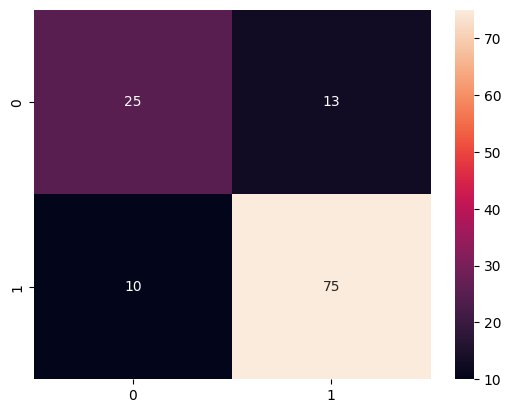

In [40]:
sns.heatmap(confusion_matrix(y_test,y_pred),
            annot=True,
            fmt='d')
plt.show()

In [41]:
y_prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.8109907120743033)

In [42]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
9,Credit_History,0.300480
5,ApplicantIncome,0.185539
7,LoanAmount,0.167272
6,CoapplicantIncome,0.102114
10,Property_Area,0.050553
2,Dependents,0.048702
8,Loan_Amount_Term,0.048430
1,Married,0.026604
4,Self_Employed,0.025800
0,Gender,0.022364


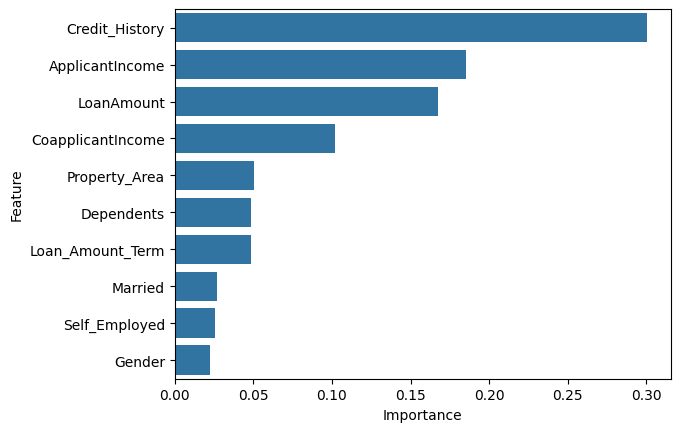

In [43]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.sort_values(
        by='Importance',
        ascending=False
    ).head(10)
)
plt.show()

In [44]:
0.50

0.5